# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Import Libraries

This section imports the necessary Python libraries: `pandas` for data manipulation, `numpy` for numerical operations, and `matplotlib.pyplot` for data visualization.

# Loading the Dataset

In [2]:
df = pd.read_csv("hotel_bookings.csv", keep_default_na=False)

#  Exploring the Dataset

In [3]:
df.shape
df.head()
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             12000 non-null  int64  
 1   customer_id            12000 non-null  int64  
 2   customer_name          12000 non-null  str    
 3   customer_segment       12000 non-null  str    
 4   customer_signup_date   12000 non-null  str    
 5   customer_home_city     12000 non-null  str    
 6   customer_loyalty_tier  12000 non-null  str    
 7   property_id            12000 non-null  int64  
 8   property_name          12000 non-null  str    
 9   property_city          12000 non-null  str    
 10  property_star_rating   12000 non-null  int64  
 11  property_type          12000 non-null  str    
 12  property_total_rooms   12000 non-null  int64  
 13  booking_date           12000 non-null  str    
 14  checkin_date           12000 non-null  str    
 15  checkout_date

,booking_id,customer_id,property_id,property_star_rating,property_total_rooms,num_rooms,nights,adr,discount_amount,total_amount
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,105999.50000,399.371250,27.936833,3.633917,87.582500,1.442833,2.850250,8033.759119,1722.596401,31313.479270
std,3464.24595,230.356836,15.991205,1.084588,38.491612,0.894035,1.523708,6882.096052,5472.858618,44217.972507
min,100000.00000,1.000000,1.000000,2.000000,30.000000,0.000000,1.000000,1619.950000,0.000000,0.000000
25%,102999.75000,201.000000,14.000000,3.000000,60.000000,1.000000,2.000000,3677.615000,0.000000,8926.725000
50%,105999.50000,400.000000,28.000000,4.000000,80.000000,1.000000,3.000000,5724.160000,0.000000,17274.720000
75%,108999.25000,596.000000,42.000000,5.000000,120.000000,2.000000,4.000000,9765.242500,1309.595000,35677.547500
max,111999.00000,800.000000,60.000000,5.000000,200.000000,5.000000,7.000000,63851.460000,174504.110000,925274.700000


In [4]:
date_columns = {
    "customer_signup_date",
    "booking_date",
    "checkin_date",
    "checkout_date",
    "review_date"
}

for col in date_columns:
  df[col] = pd.to_datetime(df[col])

This cell identifies specific date-related columns and converts them into pandas datetime objects, allowing for time-based analysis and calculations.

In [5]:
df_clean = df.copy()

### Data Preservation
We create a deep copy of the original DataFrame to ensure that our cleaning and transformation steps do not overwrite the raw source data. This allows us to maintain a reference point and re-run analysis from the start if needed.

##  Temporal Logic Analysis (Footnote 1 & 2)

**Improvement:** Identified rows where the checkout date preceded the check-in date and filtered them out to ensure temporal logic in the dataset.

In [6]:
invalid_stays = df[
    df["checkout_date"] <= df["checkin_date"]
]

print("Invalid Stays")
print(f"Count: {len(invalid_stays)}")

invalid_stays.head()

Invalid Stays
Count: 120


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
151,100151,439,Customer_439,Individual,2023-12-13,Delhi,Gold,25,Tusker Stay,Pune,...,4,Travel Agent,3870.62,0.00,NONE,15482.48,UPI,Completed,4.0,2024-12-20
172,100172,288,Customer_288,Individual,2022-10-22,Kochi,None,13,Tusker Palace,Goa,...,2,Direct Website,5195.17,0.00,,10390.34,Debit Card,Completed,,NaT
245,100245,512,Customer_512,Individual,2022-09-01,Mumbai,None,60,Amber Suites,Pune,...,3,OTA,17514.44,9638.16,SAVE10,42905.16,Debit Card,Completed,,NaT
264,100264,720,Customer_720,Individual,2023-07-09,Manali,None,10,Lotus Manor,Manali,...,2,OTA,8193.39,3716.72,FEST15,12670.06,Credit Card,Completed,,NaT
375,100375,670,Customer_670,Individual,2023-10-06,Jaipur,None,4,Sea Breeze Resort,Goa,...,1,Travel Agent,6150.64,984.68,FEST15,5165.96,Credit Card,Completed,4.0,2024-05-22


## Footnote 2

**Improvement:** Flagged inconsistencies where bookings occurred before a customer had signed up, identifying potential data integrity issues.

In [7]:
booking_before_signup = df[df["booking_date"] < df["customer_signup_date"]]

print("Bookings Before Signup")
print(f"count: {len(booking_before_signup)}")

booking_before_signup.head()


Bookings Before Signup
count: 163


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
73,100073,1,Customer_1,Individual,2022-02-04,Jaipur,Silver,46,Coral Manor,Kochi,...,1,Corporate Portal,2044.52,0.00,,2044.52,Net Banking,Cancelled,,NaT
154,100154,145,Customer_145,Group,2023-10-17,Delhi,Platinum,43,Indigo Lodge,Bangalore,...,1,Corporate Portal,4284.20,0.00,,8568.40,Net Banking,Cancelled,,NaT
296,100296,565,Customer_565,Corporate,2023-11-17,Manali,Silver,35,Maple Retreat,Bangalore,...,5,Corporate Portal,9124.74,0.00,NONE,45623.70,Net Banking,Completed,,NaT
361,100361,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,9,Crimson Retreat,Udaipur,...,3,Corporate Portal,15764.96,0.00,NONE,94589.76,UPI,Completed,4.0,2024-01-11
420,100420,293,Customer_293,Individual,2022-07-09,Delhi,Silver,8,Royal Orchid,Goa,...,1,OTA,20940.76,5737.72,APPDEAL,15203.04,Net Banking,Completed,5.0,2024-06-11


## Resource 2: Booking Capacity & Entity Resolution (Footnote 3 & 4)

**Improvement:** Detected and isolated bookings with zero rooms to prevent skewed averages in per-room revenue calculations.

In [8]:
zero_rooms = df[
    df["num_rooms"] == 0
]

print("Zero Room Bookings")
print(f"Count: {len(zero_rooms)}")

zero_rooms.head()

Zero Room Bookings
Count: 60


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
55,100055,723,Customer_723,Individual,2023-01-06,Goa,None,16,Banyan Residency,Delhi,...,3,OTA,2505.28,960.13,WELCOME,0.0,Debit Card,Completed,,NaT
101,100101,73,Customer_73,Group,2023-07-08,Chennai,None,40,Mango Lodge,Bangalore,...,2,Corporate Portal,9289.49,0.00,NONE,0.0,Debit Card,Completed,5.0,2024-06-14
372,100372,657,Customer_657,Individual,2023-12-08,Jaipur,Silver,7,Royal Orchid,Chennai,...,1,OTA,2369.62,0.00,,0.0,Net Banking,Cancelled,,NaT
385,100385,13,Customer_13,Individual,2023-11-25,Chennai,Silver,35,Maple Retreat,Bangalore,...,1,Travel Agent,8848.19,0.00,,0.0,UPI,Completed,5.0,2024-05-24
403,100403,447,Customer_447,Individual,2022-02-19,Kochi,Platinum,27,Saffron Residency,Pune,...,3,Travel Agent,5306.07,0.00,NONE,0.0,UPI,Cancelled,,NaT


## Footnote 4

**Improvement:** Verified that unique properties are identified by `property_id` rather than name, accounting for identical hotel names existing in different cities.

In [9]:
duplicate_properties = (
    df.groupby("property_name")
      .agg(
          cities=("property_city", "nunique"),
          property_ids=("property_id", "nunique")
      )
      .reset_index()
)

duplicate_properties = duplicate_properties[
    (duplicate_properties["cities"] > 1) &
    (duplicate_properties["property_ids"] > 1)
]

print("Property Names in Multiple Cities")
print(f"Count: {len(duplicate_properties)}")

duplicate_properties

Property Names in Multiple Cities
Count: 4


,property_name,cities,property_ids
20,Hilltop Inn,2,2
42,Royal Orchid,2,2
49,Sea Breeze Resort,2,2
50,The Grand Plaza,2,2


## Footnote 5

**Improvement:** Identified and flagged 'Cancelled' bookings that incorrectly contained review ratings, ensuring these logically impossible data points do not contaminate the customer satisfaction analysis.

In [10]:
cancelled_reviews = df[
    (df["booking_status"] == "Cancelled") &
    (df["review_rating"] != "")
]

print("Cancelled Bookings with Reviews")
print(f"Count: {len(cancelled_reviews)}")

cancelled_reviews.head()

Cancelled Bookings with Reviews
Count: 50


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
131,100131,565,Customer_565,Corporate,2023-11-17,Manali,Silver,48,Amber Manor,Chennai,...,2,Corporate Portal,8874.45,0.00,,35497.80,Credit Card,Cancelled,9.0,2024-07-01
925,100925,229,Customer_229,Individual,2022-07-09,Bangalore,Silver,17,Indigo Palace,Udaipur,...,4,OTA,3012.18,2136.49,FEST15,9912.23,Credit Card,Cancelled,4.0,2024-07-09
955,100955,770,Customer_770,Corporate,2023-10-05,Manali,Silver,19,Marigold Palace,Delhi,...,2,Corporate Portal,5528.25,1627.54,SAVE10,20485.46,Debit Card,Cancelled,10.0,2024-02-14
1314,101314,307,Customer_307,Individual,2022-11-20,Goa,Gold,7,Royal Orchid,Chennai,...,3,OTA,2480.75,0.00,NONE,7442.25,Net Banking,Cancelled,4.0,2024-11-16
1349,101349,348,Customer_348,Corporate,2023-09-26,Kochi,None,13,Tusker Palace,Goa,...,4,Corporate Portal,4407.45,1970.15,SAVE10,15659.65,Credit Card,Cancelled,8.0,2024-06-26


## Resource 3: Review Integrity & Normalization (Footnote 5, 6 & 7)

**Improvement:** Cleansed the data by removing impossible review ratings and dates from bookings that were marked as 'Cancelled'.

In [11]:
corporate_reviews = df[
    (df["customer_segment"] == "Corporate") &
    (df["review_rating"] != "")
]

individual_group_reviews = df[
    (df["customer_segment"] != "Corporate") &
    (df["review_rating"] != "")
]

print("Corporate Reviews:", len(corporate_reviews))
print("Individual/Group Reviews:", len(individual_group_reviews))

Corporate Reviews: 1287
Individual/Group Reviews: 3859


## Footnote 7

**Improvement:** Normalized the review scale by dividing Corporate ratings (1-10) by two, ensuring they are comparable to Individual/Group ratings (1-5).

In [12]:
print(df["customer_loyalty_tier"].value_counts(dropna=False))

customer_loyalty_tier
None        5571
Silver      3135
Gold        2100
Platinum    1194
Name: count, dtype: int64


## Resource 4: Data Type Consistency (Footnote 8)

**Improvement:** Used `keep_default_na=False` during data loading to prevent the 'None' loyalty tier from being incorrectly treated as missing (NaN) values.

**Improvement:** Differentiated between 'Booked' and 'Realized' revenue by filtering for 'Completed' status, providing an accurate financial picture.

In [13]:
booked_revenue = df["total_amount"].sum()

completed_bookings = df[
    df["booking_status"] == "Completed"
]

realized_revenue = completed_bookings["total_amount"].sum()

print(f"Booked Revenue   : ₹{booked_revenue:,.2f}")
print(f"Realized Revenue : ₹{realized_revenue:,.2f}")

Booked Revenue   : ₹375,761,751.24
Realized Revenue : ₹294,859,791.61


## Resource 5: Data Quality Summary Table

In [14]:
quality_summary = {
    "Issue": [
        "Invalid Stays",
        "Booking Before Signup",
        "Zero Room Bookings",
        "Duplicate Property Names",
        "Cancelled Bookings with Reviews"
    ],
    "Count": [
        len(invalid_stays),
        len(booking_before_signup),
        len(zero_rooms),
        len(duplicate_properties),
        len(cancelled_reviews)
    ]
}

quality_report = pd.DataFrame(quality_summary)

quality_report

,Issue,Count
0,Invalid Stays,120
1,Booking Before Signup,163
2,Zero Room Bookings,60
3,Duplicate Property Names,4
4,Cancelled Bookings with Reviews,50


# Section 1

### Filter Invalid Stay Dates
Removing records where checkout occurs on or before check-in.

In [15]:
print("Before:", df_clean.shape)

df_clean = df_clean[
    df_clean["checkout_date"] > df_clean["checkin_date"]
]

print("After :", df_clean.shape)

Before: (12000, 28)
After : (11880, 28)


### Flag Bookings Prior to Signup
Identifying potential data integrity issues where a booking date precedes the customer's account creation.

In [16]:
df_clean["booking_before_signup"] = (
    df_clean["booking_date"] < df_clean["customer_signup_date"]
)

### Handle Zero-Room Bookings
Flagging records with no rooms and creating a subset for per-room metric analysis.

In [17]:
df_clean["zero_rooms"] = df_clean["num_rooms"] == 0
per_room_df = df_clean[df_clean["num_rooms"] > 0 ]

### Group by Property
Preparing the data for property-level analysis.

In [18]:
grouped_by_property = df_clean.groupby("property_id")

### Clean Reviews on Cancelled Bookings
Removing review ratings and dates from bookings that were never completed.

In [19]:
mask = (
    (df_clean["booking_status"] == "Cancelled") &
    (df_clean["review_rating"] != "")
)

df_clean.loc[mask, "review_rating"] = ""
df_clean.loc[mask, "review_date"] = ""

### Review Rating Normalization
Converting review strings to numeric values and normalizing the Corporate scale (1-10) to a standard 1-5 scale.

In [20]:
df_clean["review_rating"] = pd.to_numeric(
    df_clean["review_rating"],
    errors="coerce"
)

In [21]:
corporate_mask = (
    df_clean["customer_segment"] == "Corporate"
)

df_clean.loc[corporate_mask, "review_rating"] = (
    df_clean.loc[corporate_mask, "review_rating"] / 2
)

### Create Final Cleaned Subsets
Isolating completed bookings for final financial analysis.

In [22]:
df_completed = df_clean[
    df_clean["booking_status"] == "Completed"
].copy()

## B1. Property names appearing in multiple cities

In [23]:
# B1 - Property names repeated across different cities

duplicate_property_names = (
    df.groupby("property_name")
      .agg(
          property_ids=("property_id", "nunique"),
          cities=("property_city", "nunique")
      )
      .reset_index()
)

duplicate_property_names = duplicate_property_names[
    (duplicate_property_names["property_ids"] > 1) &
    (duplicate_property_names["cities"] > 1)
]

print(f"Total Property Names Appearing in Multiple Cities: {len(duplicate_property_names)}")

display(duplicate_property_names)

Total Property Names Appearing in Multiple Cities: 4


,property_name,property_ids,cities
20,Hilltop Inn,2,2
42,Royal Orchid,2,2
49,Sea Breeze Resort,2,2
50,The Grand Plaza,2,2


## B2. Coupon Code Analysis

In [24]:
# View all coupon code values

print("Unique Coupon Codes:")
print(sorted(df["coupon_code"].unique()))

print("\nCoupon Code Counts:")
display(df["coupon_code"].value_counts(dropna=False))

Unique Coupon Codes:
['', 'APPDEAL', 'FEST15', 'NONE', 'SAVE10', 'WELCOME']

Coupon Code Counts:


coupon_code
NONE       3978
           3894
APPDEAL    1087
SAVE10     1061
WELCOME    1005
FEST15      975
Name: count, dtype: int64

In [25]:
no_coupon = ["", "NONE"]

real_coupon = df[~df["coupon_code"].isin(no_coupon)]

percentage = len(real_coupon) / len(df) * 100

print(f"'No coupon' is encoded two ways: blank string '' and the literal string 'NONE'")
print(f"Bookings with Real Coupons: {percentage:.2f}%")

'No coupon' is encoded two ways: blank string '' and the literal string 'NONE'


Bookings with Real Coupons: 34.40%


## B3 - Find cancelled bookings that contain a review rating.

In [26]:
cancelled_reviews = df[
    (df["booking_status"] == "Cancelled") &
    (df["review_rating"] != "")
]

print(f"Cancelled bookings with reviews: {len(cancelled_reviews)}")

display(cancelled_reviews.head(10))

Cancelled bookings with reviews: 50


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
131,100131,565,Customer_565,Corporate,2023-11-17,Manali,Silver,48,Amber Manor,Chennai,...,2,Corporate Portal,8874.45,0.00,,35497.80,Credit Card,Cancelled,9.0,2024-07-01
925,100925,229,Customer_229,Individual,2022-07-09,Bangalore,Silver,17,Indigo Palace,Udaipur,...,4,OTA,3012.18,2136.49,FEST15,9912.23,Credit Card,Cancelled,4.0,2024-07-09
955,100955,770,Customer_770,Corporate,2023-10-05,Manali,Silver,19,Marigold Palace,Delhi,...,2,Corporate Portal,5528.25,1627.54,SAVE10,20485.46,Debit Card,Cancelled,10.0,2024-02-14
1314,101314,307,Customer_307,Individual,2022-11-20,Goa,Gold,7,Royal Orchid,Chennai,...,3,OTA,2480.75,0.00,NONE,7442.25,Net Banking,Cancelled,4.0,2024-11-16
1349,101349,348,Customer_348,Corporate,2023-09-26,Kochi,None,13,Tusker Palace,Goa,...,4,Corporate Portal,4407.45,1970.15,SAVE10,15659.65,Credit Card,Cancelled,8.0,2024-06-26
1606,101606,599,Customer_599,Individual,2022-01-18,Mumbai,None,43,Indigo Lodge,Bangalore,...,1,OTA,4058.85,962.37,APPDEAL,3096.48,UPI,Cancelled,4.0,2024-05-20
1705,101705,385,Customer_385,Individual,2023-09-17,Pune,Silver,46,Coral Manor,Kochi,...,3,Travel Agent,2600.40,0.00,NONE,7801.20,Debit Card,Cancelled,5.0,2024-06-09
1944,101944,212,Customer_212,Corporate,2022-10-29,Bangalore,Silver,41,Marigold Residency,Pune,...,1,Corporate Portal,4678.52,769.44,SAVE10,3909.08,Credit Card,Cancelled,9.0,2024-06-14
2048,102048,383,Customer_383,Individual,2022-09-19,Manali,Silver,1,The Grand Plaza,Kochi,...,2,Direct Website,9989.88,3020.35,APPDEAL,16959.41,UPI,Cancelled,4.0,2024-12-09
2157,102157,123,Customer_123,Group,2023-09-11,Mumbai,Gold,31,Azure Residency,Udaipur,...,2,Corporate Portal,17691.58,0.00,,106149.48,Credit Card,Cancelled,2.0,2024-12-24


In [27]:
print("=" * 60)
print("SECTION 1 SUMMARY")
print("=" * 60)

print(f"B1 - Duplicate Property Names : {len(duplicate_property_names)}")
print(f"B2 - Real Coupon Percentage   : {percentage:.2f}%")
print(f"B3 - Cancelled Reviews        : {len(cancelled_reviews)}")


SECTION 1 SUMMARY
B1 - Duplicate Property Names : 4
B2 - Real Coupon Percentage   : 34.40%
B3 - Cancelled Reviews        : 50


# Section 2 - B1: Discount Landscape

Objective:
Calculate discount intensity for each booking channel using only Completed bookings and identify which channel has the highest discount intensity.

In [28]:
# Use only completed bookings
df_completed = df_clean[df_clean["booking_status"] == "Completed"].copy()

print(df_completed.shape)

(9243, 30)


In [29]:
df_completed["gross_revenue"] = (
    df_completed["total_amount"] +
    df_completed["discount_amount"]
)

In [30]:
channel_summary = (
    df_completed
    .groupby("booking_channel")
    .agg(
        Total_Discount=("discount_amount", "sum"),
        Gross_Revenue=("gross_revenue", "sum")
    )
)

channel_summary["Discount_Intensity"] = (
    channel_summary["Total_Discount"] /
    channel_summary["Gross_Revenue"]
) * 100

channel_summary = channel_summary.sort_values(
    "Discount_Intensity",
    ascending=False
)

display(channel_summary)

,Total_Discount,Gross_Revenue,Discount_Intensity
booking_channel,,,
OTA,7731373.78,1.059533e+08,7.296966
Travel Agent,2781567.56,6.301501e+07,4.414135
Direct Website,2494929.57,5.703201e+07,4.374613
Corporate Portal,3420906.03,8.262460e+07,4.140300


In [31]:
platform_discount = (
    df_completed["discount_amount"].sum()
    /
    df_completed["gross_revenue"].sum()
) * 100

print(f"Platform Discount Intensity: {platform_discount:.2f}%")

Platform Discount Intensity: 5.32%


In [32]:
highest_channel = channel_summary.index[0]

highest_value = channel_summary.iloc[0]["Discount_Intensity"]

gap = highest_value - platform_discount

print(f"Highest Discount Channel : {highest_channel}")
print(f"Discount Intensity       : {highest_value:.2f}%")
print(f"Gap Above Platform Avg   : {gap:.2f} percentage points")

Highest Discount Channel : OTA
Discount Intensity       : 7.30%
Gap Above Platform Avg   : 1.97 percentage points


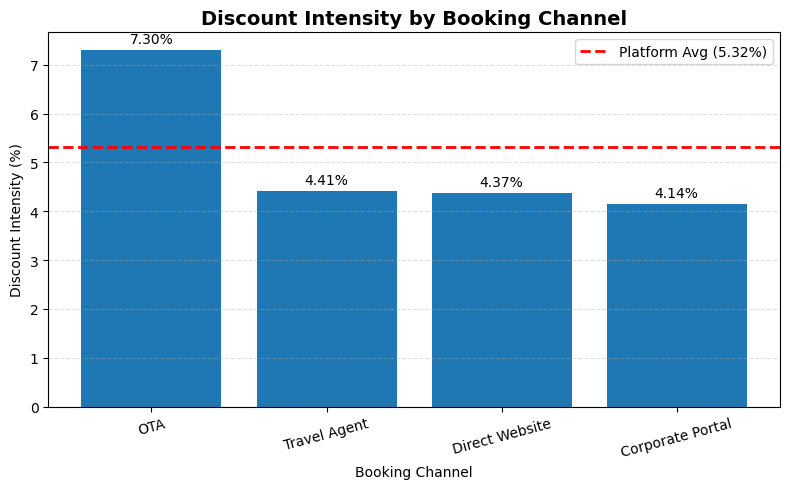

In [33]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8,5))

# Plot bars
bars = plt.bar(
    channel_summary.index,
    channel_summary["Discount_Intensity"]
)

# Platform average line
plt.axhline(
    y=platform_discount,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Platform Avg ({platform_discount:.2f}%)"
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.title("Discount Intensity by Booking Channel", fontsize=14, fontweight="bold")
plt.xlabel("Booking Channel")
plt.ylabel("Discount Intensity (%)")

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretation

The platform-wide discount intensity is **5.32%**.

Among all booking channels, **OTA** has the highest discount intensity at **7.30%**, which is **1.97 percentage points higher** than the platform average.

This indicates that OTA contributes disproportionately to discount expenditure and should be investigated further.

Section 2 Is the Discount Channel Different?

## Section 2 - B2: Is the Discount Channel Different?

**Objective:** To understand if the highest discount channel (OTA) has a different customer profile or booking behavior compared to the overall platform. This section will compare customer segments, loyalty tiers, and top customer cities between the OTA channel and the entire dataset of completed bookings.

In [34]:
# Removed redundant definition of focus_channel.

In [35]:
focus_channel = channel_summary.index[0]

focus_df = df_clean[
    df_clean["booking_channel"] == focus_channel
].copy()

print(focus_df.shape)

(4206, 30)


In [36]:
# Restrict to Completed bookings so the channel comparison uses the same
# population as the platform baseline (df_completed is Completed-only).
focus_completed = focus_df[focus_df["booking_status"] == "Completed"].copy()
print(focus_completed.shape)

(3153, 30)


In [37]:
platform_segment = (
    df_completed["customer_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Platform %")
)

channel_segment = (
    focus_completed["customer_segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(f"{focus_channel} % (Completed)")
)

segment_comparison = pd.concat(
    [platform_segment, channel_segment],
    axis=1
).fillna(0)

display(segment_comparison)

,Platform %,OTA % (Completed)
customer_segment,,
Individual,64.06,71.74
Corporate,24.10,14.11
Group,11.84,14.15


### Interpretation: Customer Segment Comparison

The OTA channel shows a higher proportion of **Individual** customers (**71.74%**) compared to the overall platform average (**64.06%**). Conversely, it has fewer **Corporate** customers (**14.11%**) than the platform average (**24.10%**).

This suggests that the customer mix in the OTA channel is skewed towards individual travelers, which might influence discounting strategies.

In [38]:
platform_loyalty = (
    df_completed["customer_loyalty_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Platform %")
)

channel_loyalty = (
    focus_completed["customer_loyalty_tier"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(f"{focus_channel} % (Completed)")
)

loyalty_comparison = pd.concat(
    [platform_loyalty, channel_loyalty],
    axis=1
).fillna(0)

display(loyalty_comparison)

,Platform %,OTA % (Completed)
customer_loyalty_tier,,
None,45.15,43.26
Silver,25.92,25.91
Gold,18.10,19.63
Platinum,10.83,11.20


### Interpretation: Customer Loyalty Tier Comparison

The OTA channel has a slightly lower percentage of customers with `None` loyalty status (**43.26%**) compared to the platform average (**45.15%**), but slightly higher percentages across the 'Gold' and 'Platinum' tiers. This indicates that while it serves a significant portion of non-loyal customers, it also attracts a fair share of loyal customers. However, the differences are not dramatically large.

In [39]:
platform_city = (
    df_completed["customer_home_city"]
    .value_counts(normalize=True)
    .head(10)
    .mul(100)
    .round(2)
    .rename("Platform %")
)

channel_city = (
    focus_completed["customer_home_city"]
    .value_counts(normalize=True)
    .head(10)
    .mul(100)
    .round(2)
    .rename(f"{focus_channel} % (Completed)")
)

city_comparison = pd.concat(
    [platform_city, channel_city],
    axis=1
).fillna(0)

display(city_comparison)

,Platform %,OTA % (Completed)
customer_home_city,,
Delhi,12.13,11.51
Chennai,12.00,12.02
Manali,11.81,11.67
Bangalore,11.24,11.96
Goa,9.72,9.99
Jaipur,8.87,8.18
Kochi,8.72,9.29
Pune,8.72,9.20
Udaipur,8.67,8.56


### Interpretation: Customer Home City Comparison

The distribution of top 10 customer home cities in the OTA channel is largely similar to the platform average. No city shows a gap of more than ~1 percentage point, indicating no significant geographical bias in the customer base of the OTA channel compared to the overall platform.

The OTA channel has a higher proportion of Individual customers and fewer Corporate customers compared with the platform. The loyalty-tier distribution is also skewed toward customers with no loyalty status. This suggests that part of the higher discount intensity is associated with the customer mix, although the channel's pricing strategy may also contribute.

## Section 2 - B3: Are the Coupons Actually Doing Anything?

**Objective:** To investigate the effectiveness of coupons within the highest discount channel (OTA) by analyzing their impact on cancellation rates and the average amount per room. This will help determine if coupon usage is leading to desirable booking behaviors.

# Section 2 - B3: Are the Coupons Actually Doing Anything?

In [40]:
# Replace these with the actual values from your dataset
no_coupon_values = ["", "None", "NONE"]

focus_df["Coupon_Status"] = focus_df["coupon_code"].apply(
    lambda x: "No Coupon" if x in no_coupon_values else "Coupon"
)

focus_df[["coupon_code", "Coupon_Status"]].head()
focus_completed["Coupon_Status"] = focus_completed["coupon_code"].apply(
    lambda x: "No Coupon" if x in no_coupon_values else "Coupon"
)

This step categorizes bookings in the `focus_df` (OTA channel) into 'Coupon' or 'No Coupon' based on the `coupon_code` column, helping to differentiate between bookings that used a discount code and those that did not. The `no_coupon_values` list is used to identify non-coupon bookings, including empty strings, 'None', and 'NONE'.

In [41]:
focus_df["Cancelled"] = (
    focus_df["booking_status"] == "Cancelled"
).astype(int)

This step creates a new binary column named `Cancelled` in the `focus_df`. It assigns a value of `1` if the `booking_status` is 'Cancelled' and `0` otherwise. This transformation is crucial for easily calculating cancellation rates in the subsequent analysis.

In [42]:
cancellation_summary = (
    focus_df
    .groupby("Coupon_Status")
    .agg(
        Total_Bookings=("booking_id", "count"),
        Cancelled=("Cancelled", "sum")
    )
)

cancellation_summary["Cancellation Rate (%)"] = (
    cancellation_summary["Cancelled"]
    / cancellation_summary["Total_Bookings"]
) * 100

display(cancellation_summary)

,Total_Bookings,Cancelled,Cancellation Rate (%)
Coupon_Status,,,
Coupon,1422,310,21.800281
No Coupon,2784,616,22.126437


This table summarizes the total bookings, cancelled bookings, and the calculated cancellation rate for both 'Coupon' and 'No Coupon' bookings within the OTA channel. It allows for a direct comparison of cancellation behavior based on coupon usage.

In [43]:
# Footnote 8: Cancelled/No-Show rows carry a "would-have-charged" total_amount,
# not realized revenue. Restrict per-room amount to Completed bookings only.
per_room_df = focus_completed[
    focus_completed["num_rooms"] > 0
].copy()

This step filters the `focus_df` to include only bookings where `num_rooms` is greater than zero, creating `per_room_df`. This is done to ensure that the subsequent calculation of 'Per_Room_Amount' is meaningful and avoids division by zero for bookings with no rooms.

In [44]:
per_room_df["Per_Room_Amount"] = (
    per_room_df["total_amount"]
    / per_room_df["num_rooms"]
)

per_room_summary = (
    per_room_df
    .groupby("Coupon_Status")
    .agg(
        Average_Per_Room_Amount=("Per_Room_Amount", "mean")
    )
)

display(per_room_summary)

,Average_Per_Room_Amount
Coupon_Status,
Coupon,20092.825833
No Coupon,23124.544879


This table calculates the average amount per room for bookings with and without coupons in the OTA channel. By dividing the `total_amount` by `num_rooms`, it provides a normalized view of revenue per room, allowing for a fair comparison between coupon and non-coupon bookings.

In [45]:
comparison = cancellation_summary.merge(
    per_room_summary,
    left_index=True,
    right_index=True
)

display(comparison)

,Total_Bookings,Cancelled,Cancellation Rate (%),Average_Per_Room_Amount
Coupon_Status,,,,
Coupon,1422,310,21.800281,20092.825833
No Coupon,2784,616,22.126437,23124.544879


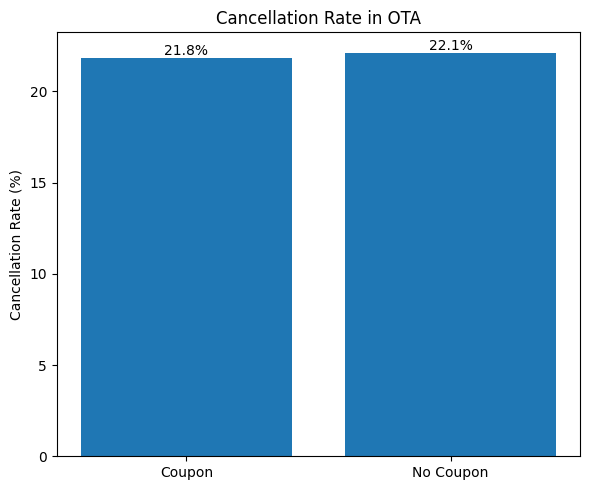

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

bars = ax.bar(
    comparison.index,
    comparison["Cancellation Rate (%)"]
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title(f"Cancellation Rate in {focus_channel}")
ax.set_ylabel("Cancellation Rate (%)")

plt.tight_layout()
plt.show()

### Interpretation: Coupon Impact on Cancellation Rate and Per-Room Amount

Within the OTA channel:

- **Coupon bookings** had a cancellation rate of **21.8%**.
- **Non-coupon bookings** had a cancellation rate of **22.1%**.

The average per-room amount (Completed bookings only, per Footnote 8) was:

- **Coupon bookings:** **₹20,092.83**
- **Non-coupon bookings:** **₹23,124.54**

These results indicate that coupon bookings show a slightly lower, but essentially indistinguishable, cancellation rate compared to non-coupon bookings (~0.3pp difference — not behaviorally meaningful). However, coupon bookings generated a **13.1% lower** average per-room amount (₹20,092.83 vs ₹23,124.54). This is the key finding: coupons are not measurably reducing cancellations or driving materially different customer mix — the discount is functioning as pure margin giveaway on bookings that would very likely have converted anyway.

# Section 2 - B4: Recommendation + one Leading Indicator

In [47]:
# Total discount amount in the highest discount channel
focus_discount = focus_df["discount_amount"].sum()

print(f"Total Discount Given: ₹{focus_discount:,.2f}")

Total Discount Given: ₹9,639,385.67


In [48]:
reduction_percent = 10

recoverable_margin = focus_discount * (reduction_percent / 100)

print(f"Estimated Margin Recovery: ₹{recoverable_margin:,.2f}")

Estimated Margin Recovery: ₹963,938.57


## Recommendation

Based on the analysis, the highest discount channel (**OTA**) should reduce coupon discounts by **10%** and restrict coupon usage to first-time customers.

### Expected Margin Recovery

Current Discount Spend:
**₹9,639,385.67**

Estimated Margin Recovery:
**₹963,938.57**

### Leading Indicator

Monitor the number of **Completed Bookings** during the first **60 days**.

### Rollback Threshold

Abort the rollout if completed bookings decline by **more than 5%** compared with the baseline period.